In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
from scipy.stats import ttest_ind

In [34]:
rates = [
    ("Resp Rate", "resp_dysfunction"),
    ("Renal Rate", "renal_dysfunction"),
    ("Cardio Rate", "cardiovasc_dysfunction"),
    ("Liver Rate", "liver_dysfunction"),
    ("CNS Rate", "cns_dysfunction"),
    ("Coag Rate", "coag_dysfunction"),
]

In [35]:
organ_weights = pd.read_csv(
    "organ_dysfunction_weights.tsv",
    sep="\t",
)

In [36]:
organ_types = [
    "Respiratory",
    "Renal",
    "Cardio",
    "Liver",
    "CNS",
    "Coagulation"
]

In [37]:
import colorcet as cc

In [38]:
colormap = cc.glasbey_cool

In [39]:
cmap = sns.color_palette(colormap, n_colors=6)

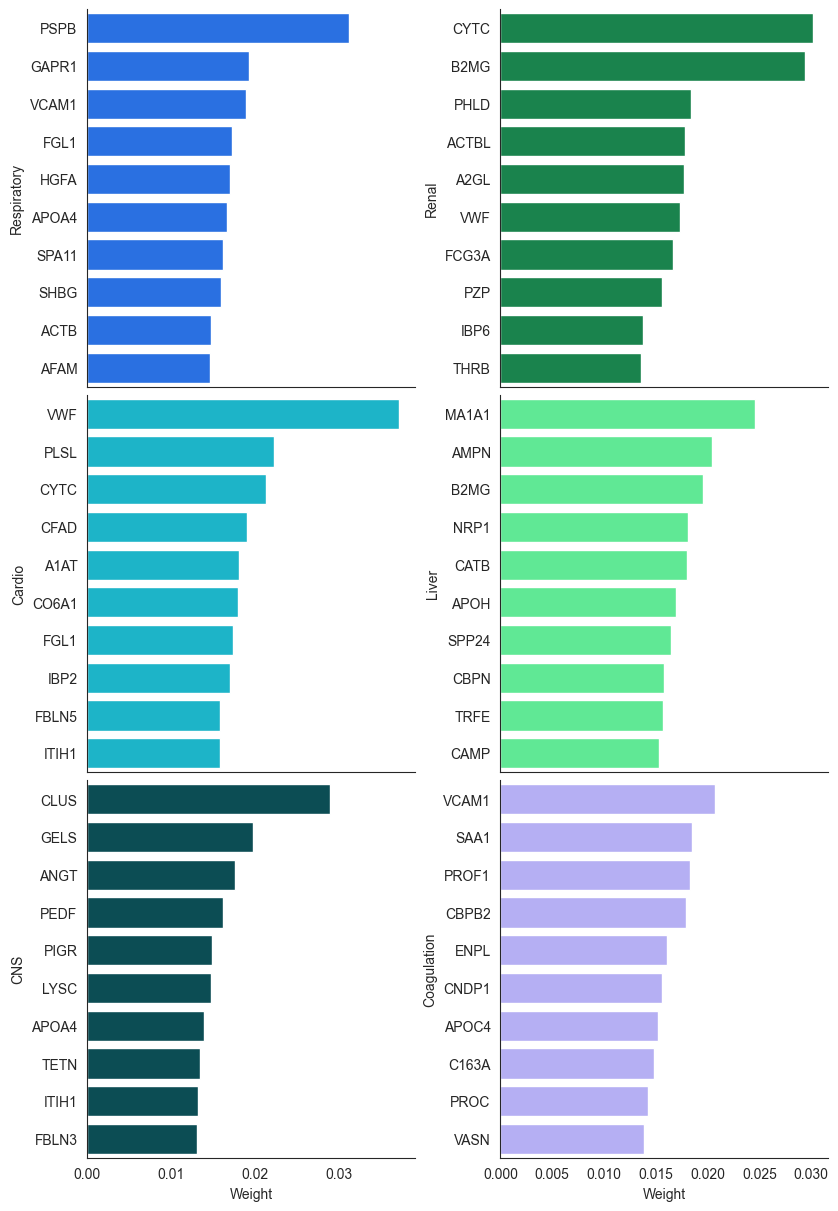

In [40]:
sns.set_style("white")

fig, axs = plt.subplots(
    nrows=3,
    ncols=2,
    constrained_layout=True,
    sharex='col'
)

axs = axs.ravel()
for i, organ in enumerate(rates):

    subset = organ_weights[organ_weights["Label"] == organ_types[i]].sort_values("Weight", ascending=False).head(10)
    subset['Feature'] = subset['Feature'].str[:-6]
    sns.barplot(
        data=subset,
        x="Weight",
        y="Feature",
        ax=axs[i],
        color=cmap[i],
    )

    axs[i].set_ylabel(organ_types[i])

sns.despine()

fig.set_size_inches(((8.27), 12))

fig.savefig(
    "organ_dys_weights.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)